#**Practice part**

In [43]:
import pandas as pd
import numpy as np

In [44]:
# understand how dot product works
w = np.array([1.2,0.5])
x = np.array([-2,1])
dot = np.dot(w,x)
dot

np.float64(-1.9)

In [45]:
# As we initialize weight and bias by random value. So we have know
r = np.random.randn(3)
r

array([ 1.57921282,  0.76743473, -0.46947439])

In [46]:
# If we want to keep just positive random value, then
r_p = np.random.rand(3)
r_p

array([0.18182497, 0.18340451, 0.30424224])

In [47]:
# To get random value fixed range
seed = np.random.seed(42)
seed

In [48]:
# AND Gate
data = {
    "x1":[0,0,1,1],
    "x2":[0,1,0,1],
    "y":[0,0,0,1]
}
AND = pd.DataFrame(data)

In [49]:
AND

,x1,x2,y
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


In [50]:
# separate x and y
# for columns drop axis 1
X = AND.drop(columns=['y'])
y = AND['y']

In [51]:
X

,x1,x2
0,0,0
1,0,1
2,1,0
3,1,1


In [52]:
y.to_frame()

,y
0,0
1,0
2,0
3,1


In [53]:
X.shape

(4, 2)

In [54]:
len(X)

4

In [55]:
bias = -np.ones((len(X),1))
bias

array([[-1.],
       [-1.],
       [-1.],
       [-1.]])

In [56]:
# Now making X with bias need to concetenate
X_withbias = np.c_[X,-np.ones((len(X),1))]

In [57]:
X_withbias

array([[ 0.,  0., -1.],
       [ 0.,  1., -1.],
       [ 1.,  0., -1.],
       [ 1.,  1., -1.]])

#**Main Part Start**

In [58]:
import matplotlib.pyplot as plt

In [59]:
class Perceptron:
  def __init__(self,eta, epochs):
    self.weights = np.random.randn(3)*1e-4
    print(f"initial weights before training: \n{self.weights}")
    self.eta =eta
    self.epochs = epochs

  def activationFunction(self,inputs, weights):
    z = np.dot(inputs, weights)
    return np.where(z>0,1,0)

  def fit(self,X,y):
    self.X = X
    self.y = y

    X_with_bias = np.c_[self.X, -np.ones((len(self.X),1))]

    print(f"X with bias: \n{X_with_bias}")

    for epoch in range(self.epochs):
      print("Epoch ",epoch)
      y_hat = self.activationFunction(X_with_bias, self.weights)
      print(f"predicted value after forward pass: \n{y_hat}")

      error = self.y - y_hat
      print(f"error: \n{error}")

      # weight updates
      self.weights = self.weights + self.eta*np.dot(X_with_bias.T, error)
      print(f"Updated weight \n {self.weights} ")

      print("##"*10)

  def predict(self,X):
    X_with_bias = np.c_[X, -np.ones((len(X),1))]
    return self.activationFunction(X_with_bias, self.weights)

# Model Prediction

In [60]:
model = Perceptron(eta=0.5,epochs = 10)
model.fit(X,y)

initial weights before training: 
[ 4.96714153e-05 -1.38264301e-05  6.47688538e-05]
X with bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
Epoch  0
predicted value after forward pass: 
[0 0 0 0]
error: 
0    0
1    0
2    0
3    1
Name: y, dtype: int64
Updated weight 
 [ 0.50004967  0.49998617 -0.49993523] 
####################
Epoch  1
predicted value after forward pass: 
[1 1 1 1]
error: 
0   -1
1   -1
2   -1
3    0
Name: y, dtype: int64
Updated weight 
 [ 4.96714153e-05 -1.38264301e-05  1.00006477e+00] 
####################
Epoch  2
predicted value after forward pass: 
[0 0 0 0]
error: 
0    0
1    0
2    0
3    1
Name: y, dtype: int64
Updated weight 
 [0.50004967 0.49998617 0.50006477] 
####################
Epoch  3
predicted value after forward pass: 
[0 0 0 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
Updated weight 
 [0.50004967 0.49998617 0.50006477] 
####################
Epoch  4
predicted value after forward pass: 
[0 0 0 1]
error: 
0    0


# OR Gate

In [61]:
data1 = {
    "x1":[0,0,1,1],
    "x2":[0,1,0,1],
     "y":[0,1,1,1]
}
OR = pd.DataFrame(data1)

In [62]:
OR

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,1


In [63]:
X = OR.drop("y",axis=1)
y = OR["y"]


In [64]:
X

,x1,x2
0,0,0
1,0,1
2,1,0
3,1,1


In [65]:
y

,y
0,0
1,1
2,1
3,1


In [66]:
y.to_frame()

,y
0,0
1,1
2,1
3,1


In [67]:
model = Perceptron(eta = 0.01,epochs=10)
model.fit(X,y)

initial weights before training: 
[ 1.52302986e-04 -2.34153375e-05 -2.34136957e-05]
X with bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
Epoch  0
predicted value after forward pass: 
[1 0 1 1]
error: 
0   -1
1    1
2    0
3    0
Name: y, dtype: int64
Updated weight 
 [ 1.52302986e-04  9.97658466e-03 -2.34136957e-05] 
####################
Epoch  1
predicted value after forward pass: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3    0
Name: y, dtype: int64
Updated weight 
 [0.0001523  0.00997658 0.00997659] 
####################
Epoch  2
predicted value after forward pass: 
[0 0 0 1]
error: 
0    0
1    1
2    1
3    0
Name: y, dtype: int64
Updated weight 
 [ 0.0101523   0.01997658 -0.01002341] 
####################
Epoch  3
predicted value after forward pass: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3    0
Name: y, dtype: int64
Updated weight 
 [ 1.01523030e-02  1.99765847e-02 -2.34136957e-05] 
####################
Epoch  4
predicted value after forward pass: 
[1 1 1 1]


# Perceptron can solve AND, OR gate easily.

# XOR Gate

In [69]:
data2 = {
    "x1":[0,0,1,1],
    "x2":[0,1,0,1],
    "y":[0,1,1,0]
}
XOR = pd.DataFrame(data2)
XOR

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [70]:
X = XOR.drop("y",axis=1)
y = XOR["y"]
y.to_frame()

,y
0,0
1,1
2,1
3,0


In [72]:
model = Perceptron(eta=0.01,epochs=100)
model.fit(X,y)

initial weights before training: 
[ 5.42560044e-05 -4.63417693e-05 -4.65729754e-05]
X with bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
Epoch  0
predicted value after forward pass: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3   -1
Name: y, dtype: int64
Updated weight 
 [-0.00994574 -0.01004634  0.01995343] 
####################
Epoch  1
predicted value after forward pass: 
[0 0 0 0]
error: 
0    0
1    1
2    1
3    0
Name: y, dtype: int64
Updated weight 
 [ 5.42560044e-05 -4.63417693e-05 -4.65729754e-05] 
####################
Epoch  2
predicted value after forward pass: 
[1 1 1 1]
error: 
0   -1
1    0
2    0
3   -1
Name: y, dtype: int64
Updated weight 
 [-0.00994574 -0.01004634  0.01995343] 
####################
Epoch  3
predicted value after forward pass: 
[0 0 0 0]
error: 
0    0
1    1
2    1
3    0
Name: y, dtype: int64
Updated weight 
 [ 5.42560044e-05 -4.63417693e-05 -4.65729754e-05] 
####################
Epoch  4
predicted value after forward pass: 
[1 1 1 

# Perceptron can not solve XOR gate.

# Plot

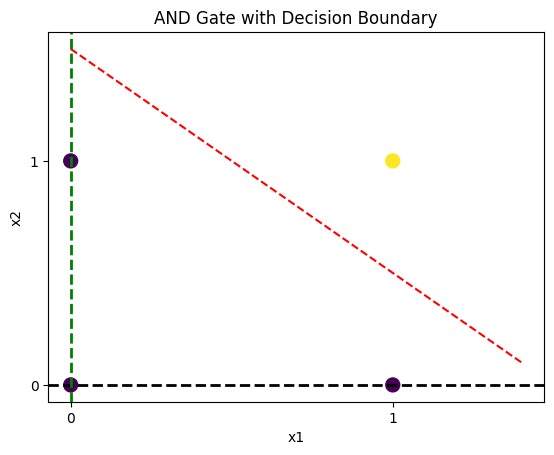

In [85]:
AND.plot(kind="scatter", x="x1", y="x2", s=100, c="y", cmap="viridis", colorbar=False)
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)  # horizontal axis
plt.axvline(x=0, color="green", linestyle="--", linewidth=2)  # vertical axis
x_line = np.linspace(0, 1.4)
y_line = 1.5 - 1*x_line
plt.plot(x_line, y_line, "r--")  # decision boundary
plt.title("AND Gate with Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.xticks([0, 1])
plt.yticks([0, 1])
# Add custom legend to distinguish classes
plt.scatter([], [], c='purple', label='y=0', s=100)
plt.scatter([], [], c='yellow', label='y=1', s=100)
plt.show()

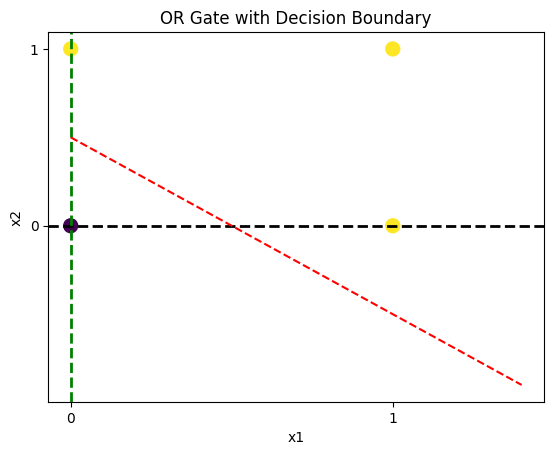

In [84]:
OR.plot(kind="scatter", x="x1", y="x2", s=100, c="y", cmap="viridis", colorbar=False)
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
plt.axvline(x=0, color="green", linestyle="--", linewidth=2)
x_line = np.linspace(0, 1.4)
y_line = 0.5 - 1*x_line
plt.plot(x_line, y_line, "r--")
plt.title("OR Gate with Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.xticks([0, 1])
plt.yticks([0, 1])
# Add custom legend to distinguish classes
plt.scatter([], [], c='purple', label='y=0', s=100)
plt.scatter([], [], c='yellow', label='y=1', s=100)
plt.show()

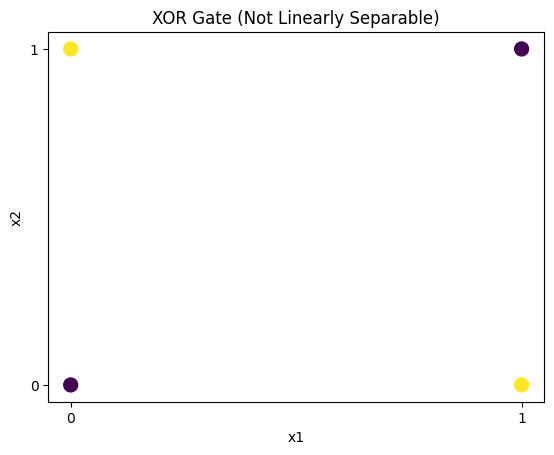

In [83]:
XOR.plot(kind="scatter", x="x1", y="x2", s=100, c="y", cmap="viridis", colorbar=False)
plt.title("XOR Gate (Not Linearly Separable)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.xticks([0, 1])
plt.yticks([0, 1])
# Add custom legend to distinguish classes
plt.scatter([], [], c='purple', label='y=0', s=100)
plt.scatter([], [], c='yellow', label='y=1', s=100)
plt.show()